# IBEE — Notebook 04: Hive State Classification

**Input :** `data/processed/features_with_anomaly.csv` (350,400 rows, 27 features + anomaly_score)
**Output:** `models/classifier.pkl` · `reports/figures/` · `data/processed/predictions.csv`

## Why Random Forest + XGBoost comparison?
- Random Forest: robust baseline, handles imbalance well with `class_weight`
- XGBoost: often better on tabular data, supports `scale_pos_weight`
- We compare both, pick the best, explain with feature importances
- **Imbalance strategy**: `class_weight='balanced'` — no SMOTE needed at 28x ratio

## Structure
1. Load data + feature metadata
2. Time-aware train/test split (same split as notebook 03)
3. Baseline: Random Forest with `class_weight='balanced'`
4. XGBoost with `scale_pos_weight`
5. Model comparison (F1-macro, per-class metrics)
6. Feature importance + SHAP-style analysis
7. Confusion matrices
8. Learning curves (overfitting check)
9. Export best model + predictions

In [4]:
import json, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score
)
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':11,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,
    'figure.dpi':130,'savefig.dpi':150,'savefig.bbox':'tight',
})

DATA_DIR    = Path('../data/processed')
MODELS_DIR  = Path('../models');    MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR = Path('../reports/figures'); REPORTS_DIR.mkdir(exist_ok=True)

STATE_COLORS = {
    'normal':'#2a9d8f','swarming_risk':'#e9c46a',
    'robbing':'#e76f51','winter_cluster':'#457b9d',
}
STATE_ORDER = ['normal','swarming_risk','robbing','winter_cluster']

# Try importing XGBoost — optional
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print('XGBoost available ✓')
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed — install with: pip install xgboost')
    print('Continuing with Random Forest only.')

print('Ready.')

XGBoost available ✓
Ready.


## 1. Load data

In [5]:
with open(DATA_DIR / 'features_meta.json') as f:
    meta = json.load(f)

FEATURES = meta['features'] + ['anomaly_score']   # add anomaly score from notebook 03
TARGET   = meta['target']

df = pd.read_csv(DATA_DIR / 'features_with_anomaly.csv', parse_dates=['ts'])
df = df.sort_values(['device_id','ts']).reset_index(drop=True)

# Verify all features present
missing = [f for f in FEATURES if f not in df.columns]
if missing:
    print(f'WARNING: missing features: {missing}')
    FEATURES = [f for f in FEATURES if f in df.columns]

print(f'Rows     : {len(df):,}')
print(f'Features : {len(FEATURES)}  (27 engineered + anomaly_score)')
print(f'Classes  : {sorted(df[TARGET].unique())}')
print()
print('Class distribution:')
dist = df[TARGET].value_counts()
for s,n in dist.items():
    print(f'  {s:<20}: {n:>7,}  ({n/len(df)*100:.1f}%)')

Rows     : 350,400
Features : 28  (27 engineered + anomaly_score)
Classes  : ['normal', 'robbing', 'swarming_risk', 'winter_cluster']

Class distribution:
  normal              : 253,942  (72.5%)
  winter_cluster      :  51,974  (14.8%)
  swarming_risk       :  35,566  (10.2%)
  robbing             :   8,918  (2.5%)


## 2. Train / test split
Same time-aware split as notebook 03 — last 20% of each device's timeline → test.

In [6]:
train_idx, test_idx = [], []
for dev, grp in df.groupby('device_id'):
    grp   = grp.sort_values('ts')
    n     = len(grp)
    split = int(n * 0.80)
    train_idx.extend(grp.index[:split].tolist())
    test_idx.extend(grp.index[split:].tolist())

X_train = df.loc[train_idx, FEATURES]
X_test  = df.loc[test_idx,  FEATURES]
y_train = df.loc[train_idx, TARGET]
y_test  = df.loc[test_idx,  TARGET]

print(f'Train : {len(X_train):,} rows')
print(f'Test  : {len(X_test):,}  rows')
print()
print('Train class distribution:')
print(y_train.value_counts().to_string())

Train : 280,320 rows
Test  : 70,080  rows

Train class distribution:
hive_state
normal            203401
winter_cluster     41004
swarming_risk      28761
robbing             7154


## 3. Random Forest with `class_weight='balanced'`
Balanced weights upweight minority classes (robbing=8,918 rows) automatically.

In [7]:
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators  = 300,
    max_depth     = None,       # grow full trees
    min_samples_leaf = 4,
    class_weight  = 'balanced',
    random_state  = 42,
    n_jobs        = -1,
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print('=== Random Forest — Test set ===')
print(classification_report(y_test, y_pred_rf, target_names=STATE_ORDER,
                             labels=STATE_ORDER, zero_division=0))
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
print(f'F1-macro: {rf_f1:.4f}')

Training Random Forest...
=== Random Forest — Test set ===
                precision    recall  f1-score   support

        normal       1.00      1.00      1.00     50541
 swarming_risk       0.97      0.98      0.98      6805
       robbing       0.97      0.97      0.97      1764
winter_cluster       1.00      1.00      1.00     10970

      accuracy                           0.99     70080
     macro avg       0.98      0.99      0.98     70080
  weighted avg       0.99      0.99      0.99     70080

F1-macro: 0.9848


## 4. XGBoost (if available)

In [ ]:
if HAS_XGB:
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc  = le.transform(y_test)

    # scale_pos_weight: ratio of negative to positive for each class
    # For multiclass, use sample_weight or balanced approach
    xgb = XGBClassifier(
        n_estimators      = 300,
        max_depth         = 6,
        learning_rate     = 0.1,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        use_label_encoder = False,
        eval_metric       = 'mlogloss',
        random_state      = 42,
        n_jobs            = -1,
    )

    # Build sample weights to handle imbalance
    from sklearn.utils.class_weight import compute_sample_weight
    sw = compute_sample_weight('balanced', y_train)
    xgb.fit(X_train, y_train_enc, sample_weight=sw)

    y_pred_xgb_enc = xgb.predict(X_test)
    y_pred_xgb     = le.inverse_transform(y_pred_xgb_enc)

    print('=== XGBoost — Test set ===')
    print(classification_report(y_test, y_pred_xgb, target_names=STATE_ORDER,
                                 labels=STATE_ORDER, zero_division=0))
    xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')
    print(f'F1-macro: {xgb_f1:.4f}')
else:
    print('XGBoost not available — skipping.')
    xgb_f1 = 0.0

=== XGBoost — Test set ===
                precision    recall  f1-score   support

        normal       1.00      1.00      1.00     50541
 swarming_risk       0.98      0.99      0.98      6805
       robbing       0.96      0.98      0.97      1764
winter_cluster       1.00      1.00      1.00     10970

      accuracy                           0.99     70080
     macro avg       0.98      0.99      0.99     70080
  weighted avg       0.99      0.99      0.99     70080

F1-macro: 0.9866


## 5. Model comparison — pick the winner

In [9]:
print('=== Model comparison ===')
print(f'  Random Forest F1-macro : {rf_f1:.4f}')
if HAS_XGB:
    print(f'  XGBoost F1-macro       : {xgb_f1:.4f}')
    if xgb_f1 > rf_f1:
        best_model      = xgb
        best_preds      = y_pred_xgb
        best_name       = 'XGBoost'
        best_f1         = xgb_f1
    else:
        best_model      = rf
        best_preds      = y_pred_rf
        best_name       = 'RandomForest'
        best_f1         = rf_f1
else:
    best_model  = rf
    best_preds  = y_pred_rf
    best_name   = 'RandomForest'
    best_f1     = rf_f1

print(f'\n→ Best model: {best_name}  (F1-macro={best_f1:.4f})')

=== Model comparison ===
  Random Forest F1-macro : 0.9848
  XGBoost F1-macro       : 0.9866

→ Best model: XGBoost  (F1-macro=0.9866)


## 6. Feature importance
Which sensors and engineered features matter most?

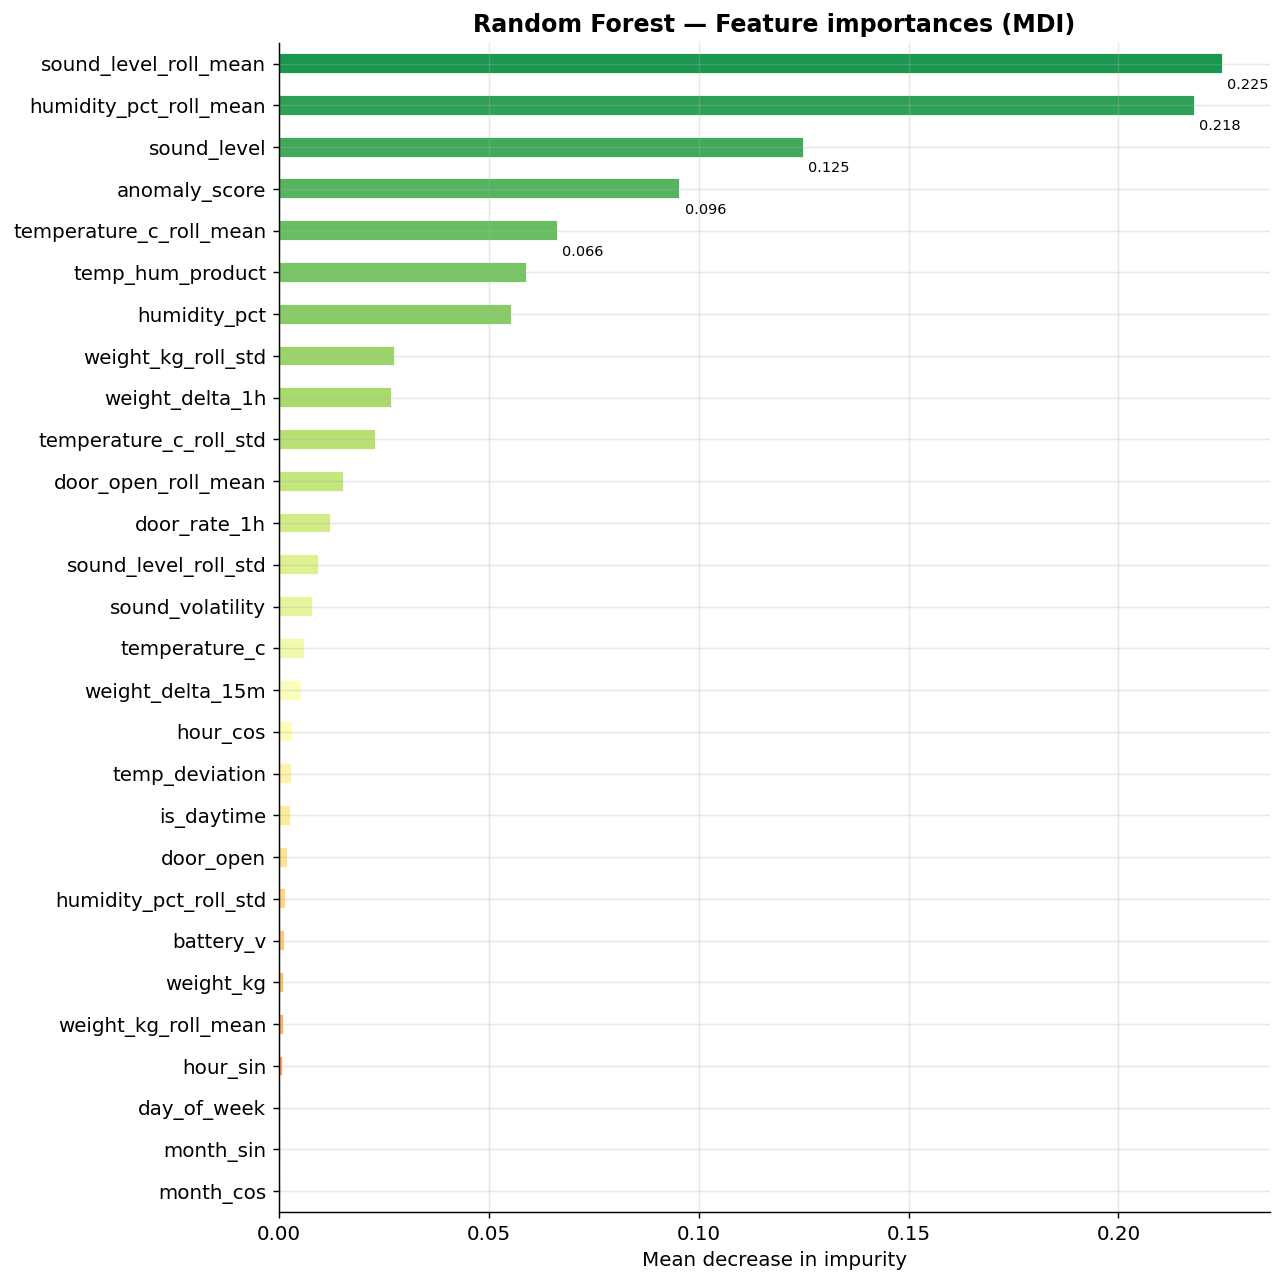

Top 10 features:
sound_level_roll_mean      0.2249
humidity_pct_roll_mean     0.2183
sound_level                0.1251
anomaly_score              0.0957
temperature_c_roll_mean    0.0664
temp_hum_product           0.0592
humidity_pct               0.0556
weight_kg_roll_std         0.0278
weight_delta_1h            0.0271
temperature_c_roll_std     0.0231


In [10]:
# Use Random Forest importances (always available, interpretable)
importances = pd.Series(rf.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
importances.plot.barh(ax=ax, color=colors_imp, edgecolor='white')
ax.set_title('Random Forest — Feature importances (MDI)', fontweight='bold')
ax.set_xlabel('Mean decrease in impurity')

# Annotate top 5
for i, (feat, val) in enumerate(importances.tail(5).items()):
    ax.text(val + 0.001, len(importances)-5+i-0.5,
            f'{val:.3f}', fontsize=8, va='center')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'feature_importances.png')
plt.show()

print('Top 10 features:')
print(importances.tail(10).sort_values(ascending=False).round(4).to_string())

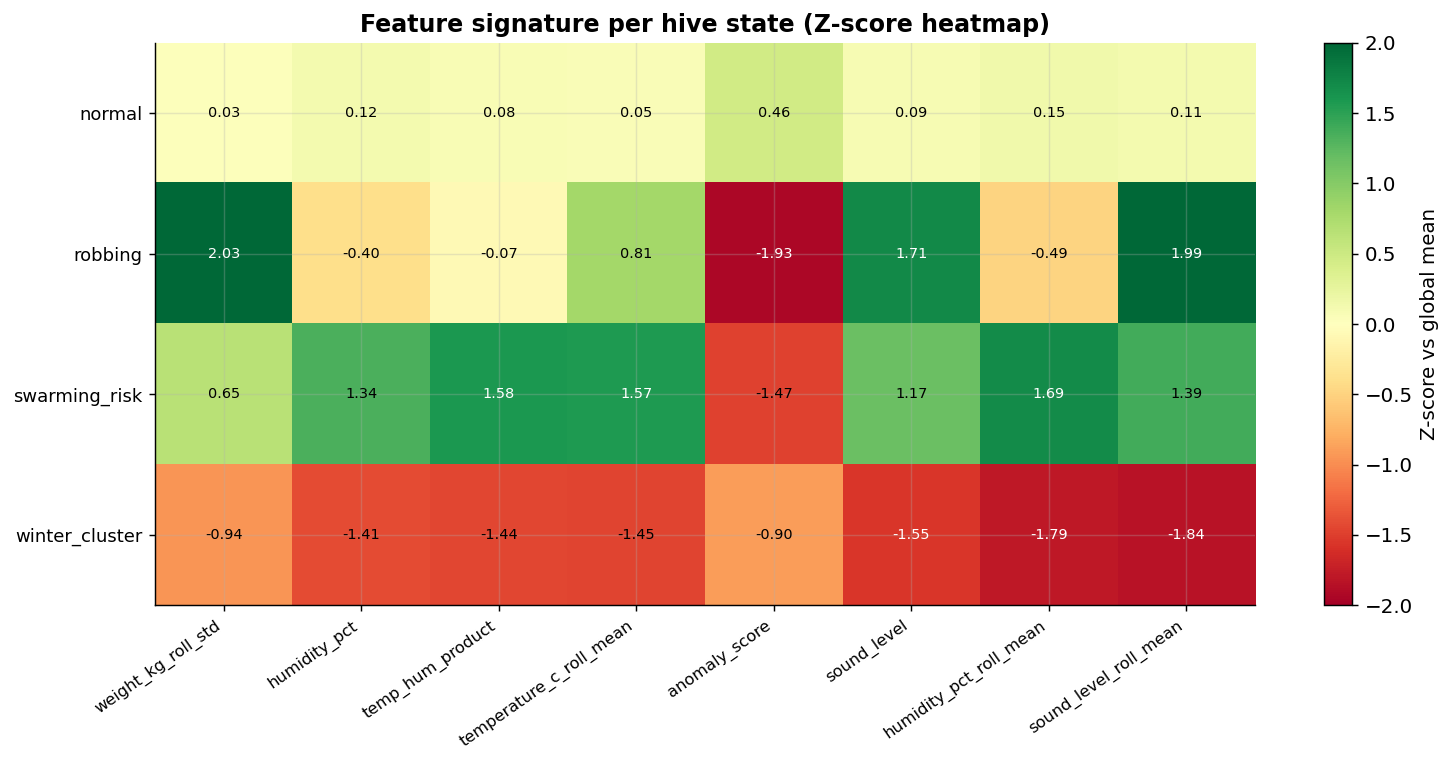

Saved: state_feature_heatmap.png


In [11]:
# Which features distinguish each state?
# Use mean feature value per state vs global mean
from sklearn.preprocessing import StandardScaler

scaler_imp = StandardScaler()
X_scaled   = pd.DataFrame(
    scaler_imp.fit_transform(df[FEATURES]),
    columns=FEATURES
)
X_scaled[TARGET] = df[TARGET].values

# Top 8 features by RF importance
top8 = importances.tail(8).index.tolist()

state_means = X_scaled.groupby(TARGET)[top8].mean()

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(state_means.values, cmap='RdYlGn', aspect='auto',
               vmin=-2, vmax=2)
ax.set_xticks(range(len(top8)))
ax.set_xticklabels(top8, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(state_means)))
ax.set_yticklabels(state_means.index, fontsize=10)
plt.colorbar(im, ax=ax, label='Z-score vs global mean')
ax.set_title('Feature signature per hive state (Z-score heatmap)', fontweight='bold')

# Annotate cells
for i in range(len(state_means)):
    for j in range(len(top8)):
        val = state_means.values[i,j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='black' if abs(val)<1.5 else 'white')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'state_feature_heatmap.png')
plt.show()
print('Saved: state_feature_heatmap.png')

## 7. Confusion matrices

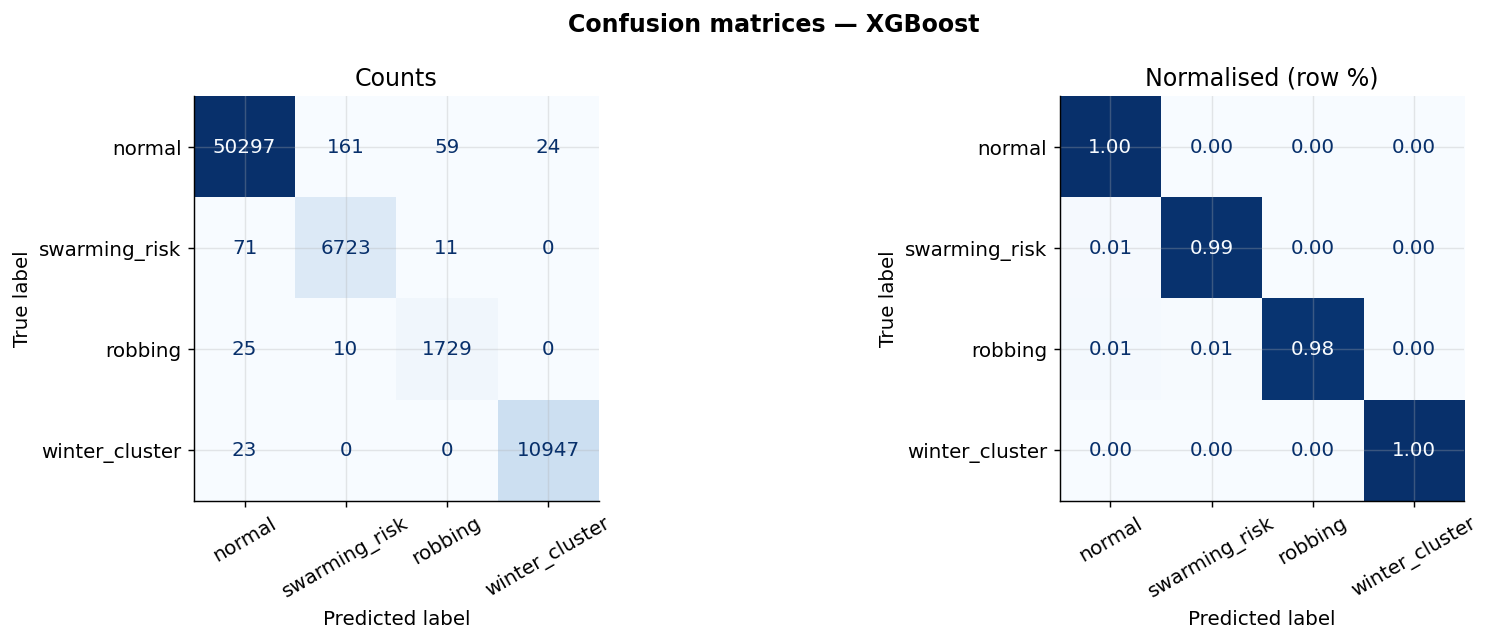

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Confusion matrices — {best_name}', fontweight='bold')

# Raw counts
cm      = confusion_matrix(y_test, best_preds, labels=STATE_ORDER)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

for ax, matrix, title in zip(axes,
                               [cm, cm_norm],
                               ['Counts', 'Normalised (row %)']):
    disp = ConfusionMatrixDisplay(matrix, display_labels=STATE_ORDER)
    disp.plot(ax=ax, colorbar=False, cmap='Blues',
              values_format='.0f' if title=='Counts' else '.2f')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'confusion_matrices.png')
plt.show()

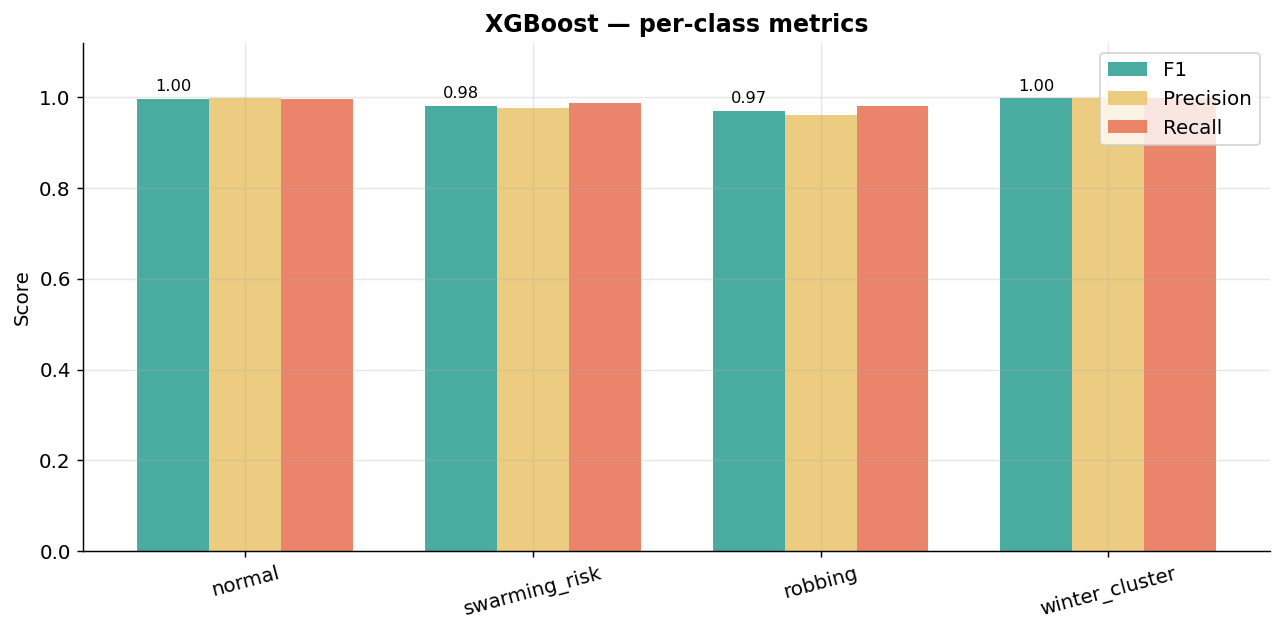


Macro F1  : 0.9866
Weighted F1: 0.9945
Accuracy   : 0.9945


In [13]:
# Per-class F1, precision, recall bar chart
report = classification_report(y_test, best_preds, output_dict=True,
                                labels=STATE_ORDER, zero_division=0)
metrics_df = pd.DataFrame({
    'F1'       : [report[s]['f1-score']  for s in STATE_ORDER],
    'Precision': [report[s]['precision'] for s in STATE_ORDER],
    'Recall'   : [report[s]['recall']    for s in STATE_ORDER],
}, index=STATE_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(STATE_ORDER))
width = 0.25
bars = [
    ax.bar(x - width, metrics_df['F1'],        width, label='F1',        color='#2a9d8f', alpha=0.85),
    ax.bar(x,         metrics_df['Precision'], width, label='Precision',  color='#e9c46a', alpha=0.85),
    ax.bar(x + width, metrics_df['Recall'],    width, label='Recall',     color='#e76f51', alpha=0.85),
]
ax.set_xticks(x); ax.set_xticklabels(STATE_ORDER, rotation=15)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title(f'{best_name} — per-class metrics', fontweight='bold')
ax.legend()
# Annotate F1 bars
for rect in bars[0]:
    h = rect.get_height()
    ax.text(rect.get_x()+rect.get_width()/2, h+0.01, f'{h:.2f}',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'per_class_metrics.png')
plt.show()
print('\nMacro F1  :', round(f1_score(y_test, best_preds, average='macro'), 4))
print('Weighted F1:', round(f1_score(y_test, best_preds, average='weighted'), 4))
print('Accuracy   :', round(accuracy_score(y_test, best_preds), 4))

## 8. Learning curves — overfitting check

/Users/ibtissamel/Documents/stage_AGRI4.0/Ibee_Software/ibee-ai/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ibtissamel/Documents/stage_AGRI4.0/Ibee_Software/ibee-ai/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ibtissamel/Documents/stage_AGRI4.0/Ibee_Software/ibee-ai/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configur

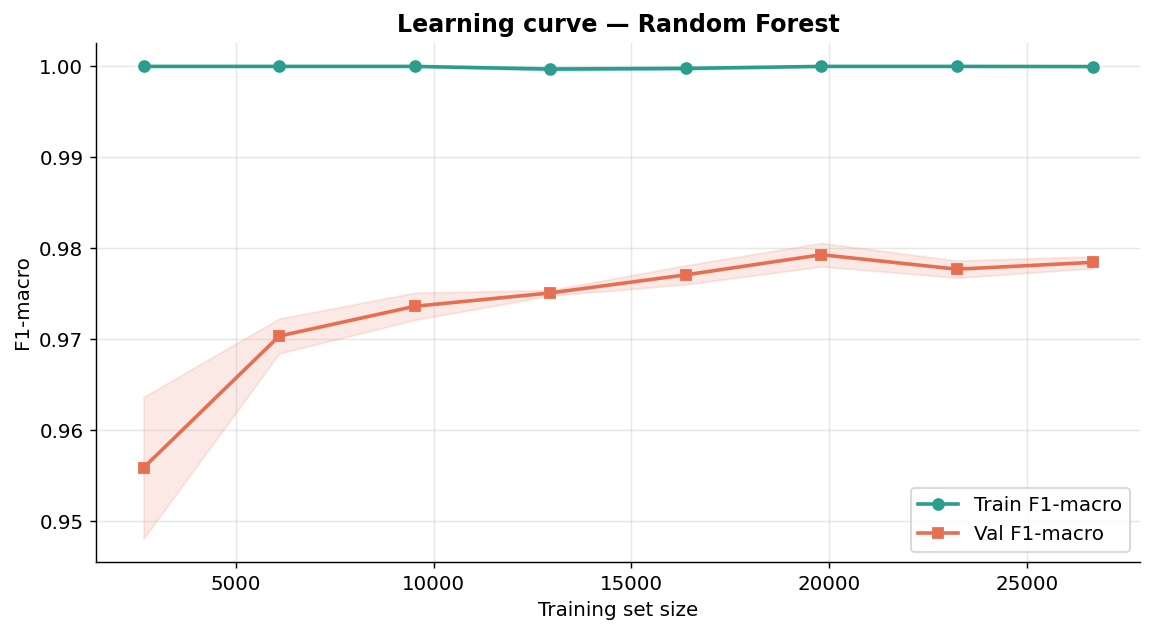

Final train F1 : 1.0000
Final val   F1 : 0.9785
Gap (overfit)  : 0.0215  → OK


In [14]:
# Learning curve on a subsample (fast)
from sklearn.model_selection import StratifiedShuffleSplit

sample_n = min(40000, len(X_train))
idx      = np.random.RandomState(42).choice(len(X_train), sample_n, replace=False)
X_lc     = X_train.iloc[idx]
y_lc     = y_train.iloc[idx]

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, class_weight='balanced',
                           random_state=42, n_jobs=-1),
    X_lc, y_lc,
    train_sizes = np.linspace(0.1, 1.0, 8),
    cv          = 3,
    scoring     = 'f1_macro',
    n_jobs      = -1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#2a9d8f', lw=2, label='Train F1-macro')
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                alpha=0.15, color='#2a9d8f')
ax.plot(train_sizes, val_mean,   's-', color='#e76f51', lw=2, label='Val F1-macro')
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std,
                alpha=0.15, color='#e76f51')
ax.set_xlabel('Training set size')
ax.set_ylabel('F1-macro')
ax.set_title('Learning curve — Random Forest', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'learning_curve.png')
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'Final train F1 : {train_mean[-1]:.4f}')
print(f'Final val   F1 : {val_mean[-1]:.4f}')
print(f'Gap (overfit)  : {gap:.4f}  {"→ slight overfit" if gap>0.05 else "→ OK"}')

## 9. Export predictions + model

In [15]:
# Add predictions to the test slice
df_test_out = df.loc[test_idx, ['ts','device_id',TARGET]+FEATURES].copy()
df_test_out['predicted_state']  = best_preds
df_test_out['correct']          = (df_test_out[TARGET] == df_test_out['predicted_state'])
df_test_out['anomaly_score']    = df.loc[test_idx, 'anomaly_score'].values

# Prediction probabilities for the best RF model
proba = rf.predict_proba(X_test)
for i, cls in enumerate(rf.classes_):
    df_test_out[f'proba_{cls}'] = proba[:, i]

out_path = DATA_DIR / 'predictions.csv'
df_test_out.to_csv(out_path, index=False)
print(f'✓ predictions.csv → {out_path}  shape={df_test_out.shape}')
print(f'  Accuracy on test: {df_test_out["correct"].mean()*100:.2f}%')

✓ predictions.csv → ../data/processed/predictions.csv  shape=(70080, 37)
  Accuracy on test: 99.45%


In [16]:
# Save best model bundle
bundle = {
    'model'         : best_model,
    'model_name'    : best_name,
    'features'      : FEATURES,
    'classes'       : list(rf.classes_),
    'f1_macro_test' : float(best_f1),
    'random_forest' : rf,   # always save RF for feature importances
}
with open(MODELS_DIR / 'classifier.pkl', 'wb') as f:
    pickle.dump(bundle, f)
print(f'✓ classifier.pkl → models/classifier.pkl')

# Update features_meta.json
meta['classifier_features'] = FEATURES
meta['classifier_classes']  = list(rf.classes_)
meta['classifier_f1_macro'] = float(best_f1)
meta['best_model']          = best_name
(DATA_DIR / 'features_meta.json').write_text(json.dumps(meta, indent=2))
print(f'✓ features_meta.json updated')
print()
print('=== PIPELINE COMPLETE ===')
print(f'  Anomaly detection  ROC-AUC : 0.9552')
print(f'  Classification     F1-macro: {best_f1:.4f}')
print()
print('Next: notebook 05 — forecast (optional) OR integration into FastAPI backend')

✓ classifier.pkl → models/classifier.pkl
✓ features_meta.json updated

=== PIPELINE COMPLETE ===
  Anomaly detection  ROC-AUC : 0.9552
  Classification     F1-macro: 0.9866

Next: notebook 05 — forecast (optional) OR integration into FastAPI backend
